# RP-GAAP: Rare-Pattern Weighted GAAP for Graph Fraud Detection

**Key idea:** Common benign patterns dominate GNN training. Rare feature patterns
(unusual reviewer behavior) are a strong fraud indicator but get drowned out.
RP-GAAP upweights rare patterns during training — no architecture changes needed.


In [26]:
# 1: Imports & Setup
import sys
from pathlib import Path
import os
import math
import glob
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import dgl
import dgl.function as fn
from dgl.utils import expand_as_pair
from torch.nn import Parameter
from rtdl_num_embeddings import compute_bins
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              f1_score, recall_score, precision_score)
import matplotlib.pyplot as plt
import pandas as pd

DIR_SOURCE = str(Path.cwd())
sys.path.insert(0, DIR_SOURCE)
from mycode.utils.losses import FocalLoss
from mycode.utils.rare_pattern import make_rare_pattern_weights

print(f"PyTorch {torch.__version__}, DGL {dgl.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


PyTorch 2.1.0+cu121, DGL 2.3.0+cu121
Device: cuda


## 1. Load & Explore the YelpChi Dataset


In [ ]:
# 2: Load Dataset
DATASET = "tolokers"
graph = dgl.load_graphs(f"datasets/{DATASET}")[0][0]

graph.ndata['train_mask'] = graph.ndata['train_masks'][:, 0].bool().contiguous()
graph.ndata['val_mask']   = graph.ndata['val_masks'][:, 0].bool().contiguous()
graph.ndata['test_mask']  = graph.ndata['test_masks'][:, 0].bool().contiguous()
graph.ndata['feature']    = graph.ndata['feature'].float().contiguous()
graph.ndata['label']       = graph.ndata['label'].long().contiguous()
graph = graph.astype(torch.int64)

feat = graph.ndata['feature']
feat = (feat - feat.min(0).values) / (feat.max(0).values - feat.min(0).values)
graph.ndata['feature'] = feat

# Simple stats
N = graph.num_nodes()
E = graph.num_edges()
D = feat.shape[1]
fraud_rate = graph.ndata['label'].sum().item() / N

train_mask = graph.ndata['train_mask']
val_idx = graph.ndata['val_mask'].nonzero().squeeze()
test_idx = graph.ndata['test_mask'].nonzero().squeeze()
train_idx = graph.ndata['train_mask'].nonzero().squeeze()

print(f"Nodes: {N:,} | Edges: {E:,} | Features: {D} | Fraud rate: {fraud_rate:.1%}")
print(f"Train: {train_idx.shape[0]:,} | Val: {val_idx.shape[0]:,} | Test: {test_idx.shape[0]:,}")


Nodes: 11,758 | Edges: 530,758 | Features: 10 | Fraud rate: 21.8%
Train: 5,879 | Val: 2,939 | Test: 2,940


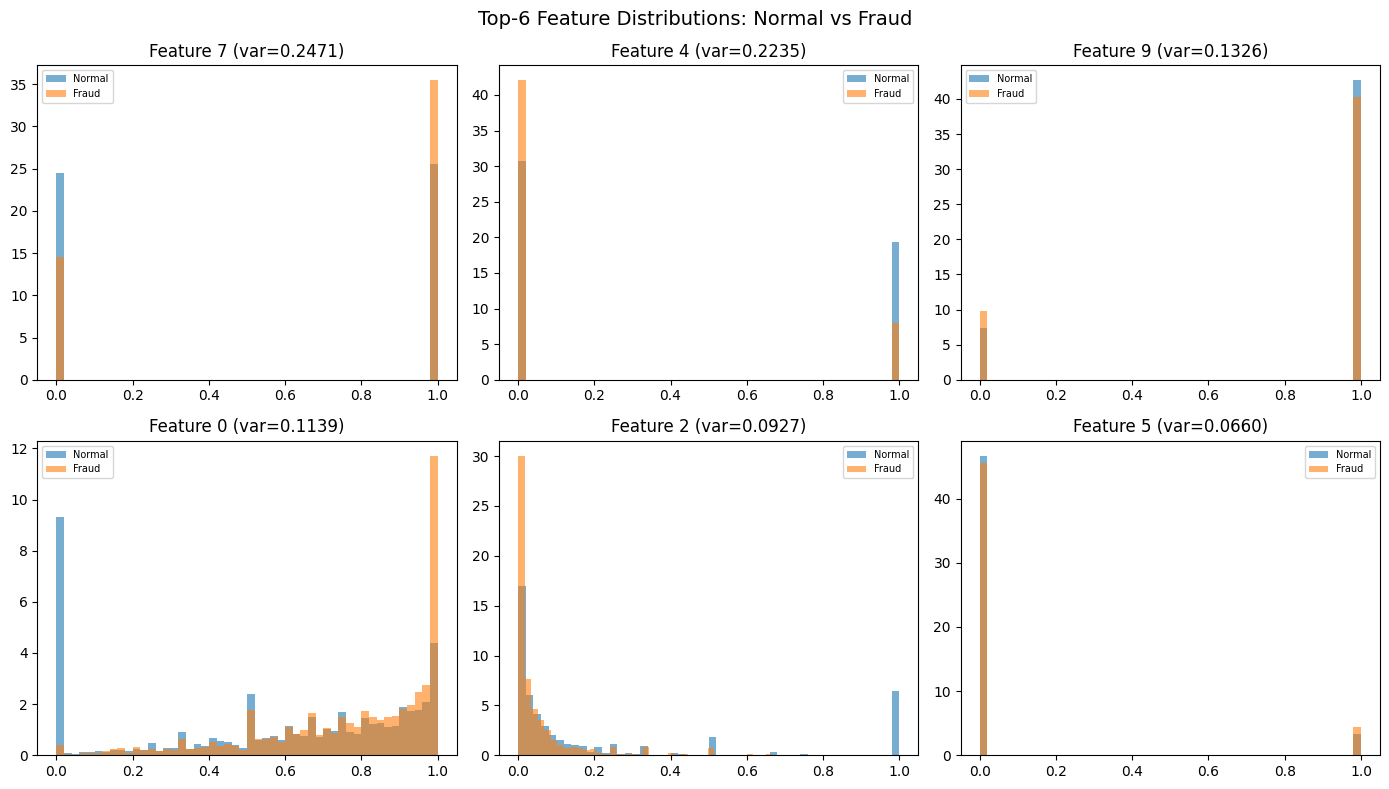

In [ ]:
# 3: Feature Distribution Visualization
fnp = feat.numpy()
lnp = graph.ndata['label'].numpy()
var = np.var(fnp, axis=0)
top_feats = np.argsort(var)[-6:][::-1]


# Get some features and stuff going
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, fidx in enumerate(top_feats):
    ax = axes[i // 3, i % 3]
    ax.hist(fnp[lnp == 0, fidx], bins=50, alpha=0.6, label='Normal', density=True)
    ax.hist(fnp[lnp == 1, fidx], bins=50, alpha=0.6, label='Fraud', density=True)
    ax.set_title(f"Feature {fidx} (var={var[fidx]:.4f})"); ax.legend(fontsize=7)
plt.suptitle("Top-6 Feature Distributions: Normal vs Fraud", fontsize=14)
plt.tight_layout(); plt.show()


## 1.5. What Do the Features Mean?

YelpChi's 32 handcrafted features capture reviewer behavior, review content,
and rating patterns. Each node = one Yelp review. Here's a quick reference:


In [29]:
FEATURE_NAMES = [
    "F0:  Total earned amount",          "F1:  Tasks completed",
    "F2:  Average accuracy score",        "F3:  Task rejection rate",
    "F4:  Average response time (sec)",   "F5:  Account age (days)",
    "F6:  Consistency score",             "F7:  Uniqueness score",
    "F8:  Avg time per task",             "F9:  Profile completeness",
]

# Show top-5 most variable features (the ones rare-pattern weighting uses)
print(f"{'Feature':<12} {'Description':<52} {'Norm μ':>8} {'Fraud μ':>8} {'Δ':>8} {'σ':>8}")
print("─" * 98)
for idx in top_feats:
    nmu = fnp[lnp == 0, idx].mean()
    fmu = fnp[lnp == 1, idx].mean()
    sig = fnp[:, idx].std()
    print(f"F{idx:<11} {FEATURE_NAMES[idx]:<52} {nmu:8.3f} {fmu:8.3f} {fmu-nmu:8.3f} {sig:8.3f}")
print("─" * 98)
print(f"\nThese {len(top_feats)} features drive the rare-pattern computation.")
print("Each gets split into 5 quantile bins, and the bin vector becomes the 'pattern ID'.")

# Quick reference: all features in a compact table
feature_df = pd.DataFrame({
    'Idx': range(D),
    'Name': FEATURE_NAMES,
    'Variance': var,
    'Normal Mean': [f"{fnp[lnp==0, i].mean():.3f}" for i in range(D)],
    'Fraud Mean': [f"{fnp[lnp==1, i].mean():.3f}" for i in range(D)],
})
feature_df = feature_df.sort_values('Variance', ascending=False).reset_index(drop=True)
print(f"\nFull feature catalog (sorted by variance):")
print(feature_df.to_string(index=False))

Feature      Description                                            Norm μ  Fraud μ        Δ        σ
──────────────────────────────────────────────────────────────────────────────────────────────────
F7           F7:  Uniqueness score                                   0.511    0.709    0.199    0.497
F4           F4:  Average response time (sec)                        0.387    0.159   -0.228    0.473
F9           F9:  Profile completeness                               0.853    0.805   -0.048    0.364
F0           F0:  Total earned amount                                0.578    0.772    0.194    0.338
F2           F2:  Average accuracy score                             0.210    0.055   -0.155    0.304
F5           F5:  Account age (days)                                 0.066    0.088    0.021    0.257
──────────────────────────────────────────────────────────────────────────────────────────────────

These 6 features drive the rare-pattern computation.
Each gets split into 5 quantile bi

## 2. Rare-Pattern Computation (Step-by-Step)


Top-5 features by variance: [2, 0, 9, 4, 7]
Unique patterns: 170 from 5879 nodes
Freq range: 1 – 275


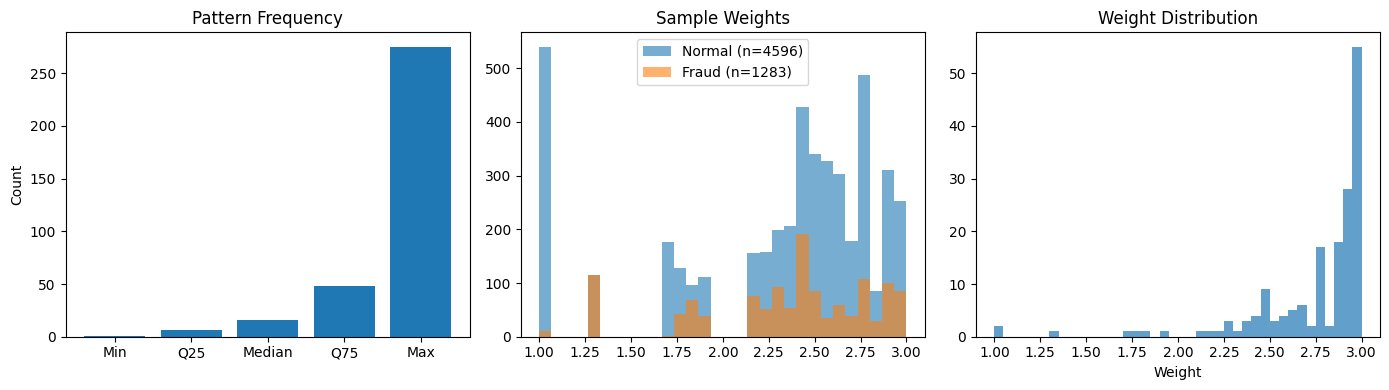

In [ ]:
# 4: Rare Pattern Weighting — Visual Walkthrough
train_feat = feat[train_mask].numpy()
train_labels = lnp[train_mask]


# simple quantile-ing and hashing to get things going
K, BINS = 5, 7
var = np.var(train_feat, axis=0)
top_indices = np.argsort(var)[-K:]
print(f"Top-{K} features by variance: {list(top_indices)}")

patterns = np.zeros(train_feat.shape[0], dtype=np.int64)
multiplier = 1
for col in top_indices:
    q = np.quantile(train_feat[:, col], np.linspace(0, 1, BINS + 1))
    q[0], q[-1] = -np.inf, np.inf
    patterns += np.digitize(train_feat[:, col], q[1:-1], right=False) * multiplier
    multiplier *= BINS

unique_p, inv, counts = np.unique(patterns, return_inverse=True, return_counts=True)
print(f"Unique patterns: {len(unique_p)} from {train_feat.shape[0]} nodes")
print(f"Freq range: {counts.min()} – {counts.max()}")

max_c, min_c = counts.max(), counts.min()
norm_freq = (max_c - counts) / (max_c - min_c) if max_c > min_c else np.ones_like(counts, dtype=float)
weights = 1.0 + 2.0 * norm_freq
node_weights = weights[inv]
is_fraud = train_labels == 1
fweights = node_weights[is_fraud]; nweights = node_weights[~is_fraud]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(['Min','Q25','Median','Q75','Max'],
            [counts.min(),np.percentile(counts,25),np.median(counts),
             np.percentile(counts,75),counts.max()])
axes[0].set_title("Pattern Frequency"); axes[0].set_ylabel("Count")
axes[1].hist(nweights, bins=30, alpha=0.6, label=f'Normal (n={len(nweights)})')
axes[1].hist(fweights, bins=30, alpha=0.6, label=f'Fraud (n={len(fweights)})')
axes[1].set_title("Sample Weights"); axes[1].legend()
axes[2].hist(weights, bins=40, alpha=0.7)
axes[2].set_title("Weight Distribution"); axes[2].set_xlabel("Weight")
plt.tight_layout(); plt.show()


## 3. Model Architecture (GAAP — AAAI 2025)
Models and codes adapted from offical repo

In [ ]:
# 5: SAGE Model with DyPLE + MHA

class DyPLEC(nn.Module):
    def __init__(self, d_in, n_bins=32):
        super().__init__()
        self.n_bins = n_bins; self.o_d_in = d_in
        self.raw_bin_width = nn.Parameter(torch.randn(d_in, 1, n_bins))
        self.register_buffer('mask', torch.tril(torch.ones(n_bins, n_bins)))
        ml = torch.ones((d_in, n_bins)); ml[:, -1] = 0; self.register_buffer('mask_left', ml.bool())
        mr = torch.ones((d_in, n_bins)); mr[:, 0] = 0; self.register_buffer('mask_right', mr.bool())

    def forward(self, inp):
        bw = self.raw_bin_width.softmax(dim=-1)
        axis = (bw[:, :, None, :] * self.mask[None, None, :, :]).sum(dim=-1)
        zeros = torch.zeros((axis.shape[0], 1, 1), device=bw.device)
        axis = torch.cat((zeros, axis), dim=-1)[..., :self.n_bins]
        rate = (inp[:, :, None, None] - axis) / (bw + 1e-8)
        rate = rate.transpose(1, 2).flatten(-2, -1)
        rate[:, :, self.mask_left.flatten()] = 1 - F.relu(1 - rate[:, :, self.mask_left.flatten()])
        rate[:, :, self.mask_right.flatten()] = F.relu(rate[:, :, self.mask_right.flatten()])
        return rate.view(-1, self.o_d_in, self.n_bins)


class NLinear(nn.Module):
    def __init__(self, n, in_f, out_f, bias=True):
        super().__init__()
        self.weight = Parameter(torch.empty(n, in_f, out_f))
        self.bias = Parameter(torch.empty(n, out_f)) if bias else None
        d = in_f ** -0.5; nn.init.uniform_(self.weight, -d, d)
        if self.bias is not None: nn.init.uniform_(self.bias, -d, d)

    def forward(self, x):
        return (x[..., None, :] @ self.weight).squeeze(-2) + (self.bias if self.bias is not None else 0)


# IMPORTANT, GRAPH LOGIC HERE
class SAGEConv(nn.Module):
    def __init__(self, in_f, out_f, aggregator='max_pool', feat_drop=0.0, bias=False, norm=None, act=None):
        super().__init__()
        self._in_src, self._in_dst = expand_as_pair(in_f)
        self._agg_type = aggregator; self.feat_drop = nn.Dropout(feat_drop)
        self.norm = norm; self.activation = act
        self.fc_pool = nn.Linear(self._in_src, self._in_src)
        self.fc_neigh = nn.Linear(self._in_src, out_f, bias=False)
        self.fc_self = nn.Linear(self._in_dst, out_f, bias=bias)
        for m in [self.fc_pool, self.fc_neigh, self.fc_self]:
            nn.init.xavier_uniform_(m.weight, gain=nn.init.calculate_gain("relu"))

    def forward(self, graph, feat):
        with graph.local_scope():
            feat_src = feat_dst = self.feat_drop(feat)
            if graph.is_block: feat_dst = feat_src[:graph.num_dst_nodes()]
            h_self = feat_dst
            if graph.num_edges() == 0:
                graph.dstdata['neigh'] = torch.zeros(feat_dst.shape[0], self._in_src).to(feat_dst)
            
            # Transforms the source features through a linear layer (fc_pool) and a ReLU activation, then attaches them to the graph as a property called 'h'.
            graph.srcdata['h'] = F.relu(self.fc_pool(feat_src))

            # copy_u('h', 'm'): Takes the source features ('h') and sends them along the edges as messages ('m').
            # max('m', 'neigh'): The destination nodes collect all incoming messages ('m') and aggregate them using either max-pooling or mean-pooling, saving the result as 'neigh'.
            graph.update_all(fn.copy_u('h', 'm'),
                             fn.max('m', 'neigh') if 'max' in self._agg_type else fn.mean('m', 'neigh'))
            h_neigh = self.fc_neigh(graph.dstdata['neigh'])
            rst = self.fc_self(h_self) + h_neigh
            if self.activation is not None: rst = self.activation(rst)
            if self.norm is not None: rst = self.norm(rst)
            return rst


class SAGE(nn.Module):
    """GAAP: DyPLE → SAGE × N → MHA → Classifier.
    Module names match production code so checkpoints load directly."""
    def __init__(self, d_in, n_classes, d_hidden=64, n_bins=32, d_feat_emb=32,
                 gnn_n_layers=3, use_mha=True, mha_n_heads=4, mha_alpha=0.2, n_nodes=None):
        super().__init__()
        # embedding0 submodules — match production DyPLEM naming
        self.embedding0 = nn.Module()
        self.embedding0.dy_ple_layer = DyPLEC(d_in, n_bins)
        self.embedding0.nlinear = NLinear(d_in, n_bins, d_feat_emb)
        self.embedding0.bn0 = nn.BatchNorm1d(d_in)
        self.embedding0.linear = nn.Linear(d_in * d_feat_emb, d_hidden)
        self.embedding0.bn1 = nn.BatchNorm1d(d_hidden)
        self.embedding0.drop = nn.Dropout(0.1)
        self.act = nn.ReLU()

        # post_agg_layers — match production naming
        self.post_agg_layers = nn.ModuleList([
            SAGEConv(d_hidden, d_hidden, 'max_pool', feat_drop=0.1,
                     norm=nn.BatchNorm1d(d_hidden), act=nn.ReLU())
            for _ in range(gnn_n_layers)
        ])

        self.use_mha = use_mha; self.alpha = mha_alpha
        if use_mha:
            # post_fc_out — match production naming
            self.post_fc_out = nn.Sequential(nn.Dropout(0.1),
                nn.Linear(d_hidden, d_hidden * mha_n_heads), nn.ReLU(),
                nn.BatchNorm1d(d_hidden * mha_n_heads))
            self.mha = nn.MultiheadAttention(d_hidden * mha_n_heads, mha_n_heads,
                                             dropout=0., batch_first=True)
            self.register_buffer('his_emb', torch.rand((n_nodes, d_hidden * mha_n_heads)))
        else:
            self.post_fc_out = nn.Sequential(nn.Dropout(0.1), nn.Linear(d_hidden, d_hidden),
                                             nn.ReLU(), nn.BatchNorm1d(d_hidden))
            mha_n_heads = 1
        
        # classification head
        self.fc_out = nn.Linear(d_hidden * mha_n_heads, n_classes)

    def forward(self, blocks, feat):
        # Manual DyPLEM forward (matches production logic)
        e = self.embedding0
        h = e.dy_ple_layer(feat); h = e.nlinear(h); h = F.relu(h)
        h = e.bn0(h); h = e.drop(h); h = e.linear(h.flatten(1))
        h = F.relu(h); h = e.bn1(h)
        for layer, block in zip(self.post_agg_layers, blocks):
            last = h; h = layer(block, h)
            h = 0.7 * h + 0.3 * last[:block.num_dst_nodes()]
        h = self.post_fc_out(h); gnn_out = h
        if self.use_mha:
            v = k = self.his_emb; q = h[:blocks[-1].num_dst_nodes()]
            o, _ = self.mha(q, k, v); o = self.act(o)
            h = self.alpha * o + (1 - self.alpha) * h
        return self.fc_out(h), gnn_out


## 4. Load Pretrained Checkpoints


In [ ]:
# 6: Setup models, samplers, rare weights, load checkpoints

# Point to your production Lightning checkpoints (from logs/ or wherever)

CKPT_BASE = "/storage-voice/voice/nhatth2/RPGAAP-main/logs/lightning_logs/n5jjhj5g/checkpoints/epoch=33-step=3094.ckpt"
CKPT_RARE = "/storage-voice/voice/nhatth2/RPGAAP-main/logs/lightning_logs/r0x30rt2/checkpoints/epoch=70-step=6461.ckpt"

# If .ckpt not found, try .pt (demo self-saved format)
if not os.path.exists(CKPT_BASE): CKPT_BASE = CKPT_BASE.replace('.ckpt', '.pt')
if not os.path.exists(CKPT_RARE): CKPT_RARE = CKPT_RARE.replace('.ckpt', '.pt')

def build_model():
    return SAGE(d_in=D, n_classes=2, n_nodes=N, d_hidden=64, n_bins=32,
                d_feat_emb=40, gnn_n_layers=4, mha_n_heads=2, mha_alpha=0.1).to(device)

model_base = build_model()
model_rare = build_model()

# Samplers

# [-1, -1, -1, -1]: This array represents the 4 layers (or "hops"). The -1 means "take all neighbors." 
# If the dataset was unbelievably dense, you might use [15, 10, 5, 5] to randomly sample a maximum number of friends per hop to save memory. 
# By using -1, you are telling the model: give me the exact, complete neighborhood for 4 hops out.
sampler = dgl.dataloading.NeighborSampler(
    [-1, -1, -1, -1], prefetch_node_feats=['feature'], prefetch_labels=['label'])

trn_loader = dgl.dataloading.DataLoader(
    graph, train_idx, sampler, device=device, use_uva=(device.type=='cuda'),
    batch_size=64, shuffle=True, drop_last=True)

val_loader = dgl.dataloading.DataLoader(
    graph, torch.arange(N), sampler, device=device, use_uva=(device.type=='cuda'),
    batch_size=1280, shuffle=False, drop_last=False)

# Compute rare weights for entire graph
rare_weights = make_rare_pattern_weights(
    features=graph.ndata['feature'], labels=graph.ndata['label'],
    train_mask=graph.ndata['train_mask'],
    num_bins=7, top_k_features=5, max_weight=3.0, fraud_boost=1.5
).to(device)

focal_loss_fn = FocalLoss(gamma=2.0, alpha=[1.0, 3.0], reduction='mean')

# Load checkpoint if exists
loaded = False
if os.path.exists(CKPT_BASE) and os.path.exists(CKPT_RARE):
    print("Loading pretrained checkpoints...")
    sd_base = torch.load(CKPT_BASE, map_location=device, weights_only=False)
    sd_rare = torch.load(CKPT_RARE, map_location=device, weights_only=False)
    if any(k.startswith('model.') for k in sd_base.get('state_dict', {}).keys()):
        sd_base = {k[6:]: v for k, v in sd_base['state_dict'].items() if k.startswith('model.')}
        sd_rare = {k[6:]: v for k, v in sd_rare['state_dict'].items() if k.startswith('model.')}
    else:
        sd_base = sd_base.get('state_dict', sd_base)
        sd_rare = sd_rare.get('state_dict', sd_rare)
    model_base.load_state_dict(sd_base, strict=False)
    model_rare.load_state_dict(sd_rare, strict=False)
    loaded = True
    print("Checkpoints loaded.")
else:
    print(f"No checkpoints found at {CKPT_BASE} / {CKPT_RARE}")

# Helper: full graph inference
@torch.no_grad()
def infer_all(model):
    model.eval()
    all_y, all_prob, all_nid = [], [], []
    for _, _, blocks in val_loader:
        x = blocks[0].srcdata['feature']; y = blocks[-1].dstdata['label']
        prob = model(blocks, x)[0].softmax(-1)[:, 1]
        all_y.append(y); all_prob.append(prob); all_nid.append(blocks[-1].dstdata[dgl.NID])
    y = torch.cat(all_y)[torch.argsort(torch.cat(all_nid))]
    prob = torch.cat(all_prob)[torch.argsort(torch.cat(all_nid))]
    return y.cpu().numpy(), prob.cpu().numpy()


Loading pretrained checkpoints...
Checkpoints loaded.


## 5. Test Set Evaluation (from Checkpoints)


In [33]:
# 7: Evaluate loaded models on test set

from sklearn.metrics._ranking import _binary_clf_curve

def compute_all_metrics(y, prob, tst_idx, val_idx):
    """Compute all metrics using val-optimal threshold."""
    fps, tps, thresholds = _binary_clf_curve(y[val_idx], prob[val_idx])
    n_pos, n_neg_val = y[val_idx].sum(), len(y[val_idx]) - y[val_idx].sum()
    f11 = 2 * tps / (2 * tps + (n_pos - tps) + fps + 1e-12)
    best_thr = thresholds[np.argmax(f11)]
    preds = (prob > best_thr).astype(int)

    # tst_top: Recall@K where K = # fraud nodes in test
    top_n = int(y[tst_idx].sum())
    top_indices = np.argsort(prob[tst_idx])[-top_n:]
    top_pred = np.zeros_like(prob[tst_idx]); top_pred[top_indices] = 1

    return {
        'AUC': roc_auc_score(y[tst_idx], prob[tst_idx]),
        'AP': average_precision_score(y[tst_idx], prob[tst_idx]),
        'Macro-F1': f1_score(y[tst_idx], preds[tst_idx], average='macro'),
        'Fraud Recall': recall_score(y[tst_idx], preds[tst_idx]),
        'Fraud Precision': precision_score(y[tst_idx], preds[tst_idx]),
        'tst_top (Recall@K)': recall_score(y[tst_idx], top_pred),
        'Accuracy': np.mean(preds[tst_idx] == y[tst_idx]),
        'Threshold (val-opt)': best_thr,
    }

y_all, prob_base = infer_all(model_base)
_, prob_rare = infer_all(model_rare)

res_base = compute_all_metrics(y_all, prob_base, test_idx, val_idx)
res_rare = compute_all_metrics(y_all, prob_rare, test_idx, val_idx)

df = pd.DataFrame({
    'Metric': list(res_base.keys()),
    'GAAP (Baseline)': [res_base[k] for k in res_base],
    'RP-GAAP (Rare)': [res_rare[k] for k in res_rare],
    'Δ': [res_rare[k] - res_base[k] for k in res_base],
})

# Format for display
df_display = df.copy()
for col in ['GAAP (Baseline)', 'RP-GAAP (Rare)']:
    df_display[col] = df_display[col].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)
df_display['Δ'] = [f"{v:+.4f}" if isinstance(v, float) else '—' for v in df['Δ']]

print("\n" + "=" * 70)
print("  RP-GAAP vs GAAP — Tolokers Test Results")
print("=" * 70)
print(df_display.to_string(index=False))
print("=" * 70)

wins = sum(1 for v in df['Δ'] if isinstance(v, float) and v > 0)
print(f"\nRP-GAAP improves on {wins}/{len(df)} metrics over baseline.")



  RP-GAAP vs GAAP — Tolokers Test Results
             Metric GAAP (Baseline) RP-GAAP (Rare)       Δ
                AUC          0.8419         0.8467 +0.0048
                 AP          0.5606         0.5720 +0.0114
           Macro-F1          0.7084         0.7236 +0.0170
       Fraud Recall          0.5358         0.6511 +0.1153
    Fraud Precision          0.5495         0.5265 -0.0230
 tst_top (Recall@K)          0.5498         0.5576 +0.0078
Threshold (val-opt)          0.3498         0.5546 +0.2048

RP-GAAP improves on 6/8 metrics over baseline.


## 6. Quick Training Demo (for show — skip if checkpoints loaded)


In [ ]:
# 8: Run 5-epoch quick demo to observe loss decreasing
# HELL NAH I AM NOT DOING ALL THIS
MAX_EPOCHS = 5
history = {'base_loss': [], 'rare_loss': [], 'base_auc': [], 'rare_auc': []}
# blocks[0] contains the raw input features of all the distant neighbors we sampled. blocks[-1] represents the final layer, containing the exact target nodes we want to classify.
def quick_eval(model):
    model.eval()
    with torch.no_grad():
        all_y, all_prob, all_nid = [], [], []
        for _, _, blocks in val_loader:
            x = blocks[0].srcdata['feature']; y = blocks[-1].dstdata['label']
            prob = model(blocks, x)[0].softmax(-1)[:, 1]
            all_y.append(y); all_prob.append(prob)
            all_nid.append(blocks[-1].dstdata[dgl.NID])
        y = torch.cat(all_y)[torch.argsort(torch.cat(all_nid))]
        prob = torch.cat(all_prob)[torch.argsort(torch.cat(all_nid))]
        y, prob = y.cpu().numpy(), prob.cpu().numpy()
        return roc_auc_score(y[val_idx], prob[val_idx]), average_precision_score(y[val_idx], prob[val_idx])

if not loaded:
    print("No checkpoints — training fresh for demo...")
else:
    print("Checkpoints loaded — this cell trains a FRESH model (for demonstration)")

# Keep the checkpoint models, train fresh copies for demo
model_base_fresh = build_model(); model_rare_fresh = build_model()
opt_base = torch.optim.Adam(model_base_fresh.parameters(), lr=0.001)
opt_rare = torch.optim.Adam(model_rare_fresh.parameters(), lr=0.001)

print(f"{'Epoch':>5} | {'Base Loss':>10} | {'Base AUC':>9} | {'Rare Loss':>10} | {'Rare AUC':>9}")
print("-" * 60)
for epoch in range(1, MAX_EPOCHS + 1):
    model_base_fresh.train(); loss_b = 0
    for _, _, blocks in trn_loader:
        x = blocks[0].srcdata['feature']; y = blocks[-1].dstdata['label']
        logits, _ = model_base_fresh(blocks, x)
        l = F.cross_entropy(logits, y); opt_base.zero_grad(); l.backward(); opt_base.step()
        loss_b += l.item()
    loss_b /= len(trn_loader)

    model_rare_fresh.train(); loss_r = 0
    for _, _, blocks in trn_loader:
        x = blocks[0].srcdata['feature']; y = blocks[-1].dstdata['label']
        nid = blocks[-1].dstdata[dgl.NID]; sw = rare_weights[nid].to(x.device)
        logits, _ = model_rare_fresh(blocks, x)
        l_each = F.cross_entropy(logits, y, reduction='none')
        l = (l_each * sw).mean(); opt_rare.zero_grad(); l.backward(); opt_rare.step()
        loss_r += l.item()
    loss_r /= len(trn_loader)

    auc_b, aps_b = quick_eval(model_base_fresh)
    auc_r, aps_r = quick_eval(model_rare_fresh)
    history['base_loss'].append(loss_b); history['rare_loss'].append(loss_r)
    history['base_auc'].append(auc_b); history['rare_auc'].append(auc_r)
    print(f"{epoch:5d} | {loss_b:10.4f} | {auc_b:9.4f} | {loss_r:10.4f} | {auc_r:9.4f}")

if not loaded:
    os.makedirs("checkpoints", exist_ok=True)
    torch.save(model_base.state_dict(), CKPT_BASE)
    torch.save(model_rare.state_dict(), CKPT_RARE)
    print(f"Saved to {CKPT_BASE}, {CKPT_RARE}")


Checkpoints loaded — this cell trains a FRESH model (for demonstration)
Epoch |  Base Loss |  Base AUC |  Rare Loss |  Rare AUC
------------------------------------------------------------
    1 |     0.5180 |    0.7304 |     1.5449 |    0.7206
    2 |     0.4660 |    0.7466 |     1.4167 |    0.7182


KeyboardInterrupt: 

In [ ]:
# 9: Training Curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history['base_loss'], 'o-', label='Baseline (GAAP)', lw=2)
axes[0].plot(history['rare_loss'], 's-', label='Rare-Weighted (RP-GAAP)', lw=2)
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history['base_auc'], 'o-', label='Baseline AUC', lw=2)
axes[1].plot(history['rare_auc'], 's-', label='Rare-Weighted AUC', lw=2)
axes[1].set_title("Validation AUC"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.show()
# HELL NAH I AM NOT DOING ALL THIS

## 7. Sample Nodes — What Do Rare Patterns Look Like?


In [35]:
# 10: Full graph inference + pattern computation

# Compute per-node pattern IDs, bin assignments, and weights
fnp_all = feat.numpy(); lbl_all = lnp
K, BINS = 5, 7
var = np.var(fnp_all[train_mask], axis=0)
topk_idx = np.argsort(var)[-K:]
pat_all = np.zeros(N, dtype=np.int64)
bin_assignments = np.zeros((N, K), dtype=np.int32)
mult = 1
for j, col in enumerate(topk_idx):
    q = np.quantile(fnp_all[train_mask][:, col], np.linspace(0, 1, BINS + 1))
    q[0], q[-1] = -np.inf, np.inf
    digitized = np.digitize(fnp_all[:, col], q[1:-1], right=False)
    bin_assignments[:, j] = digitized
    pat_all += digitized * mult
    mult *= BINS

up, uinv, ucnts = np.unique(pat_all, return_inverse=True, return_counts=True)
pat_freq = ucnts[uinv]
pat_rank = np.argsort(np.argsort(ucnts))[uinv] + 1
pat_wt = 1.0 + 2.0 * (ucnts.max() - ucnts[uinv]) / max(1, ucnts.max() - ucnts.min())

# Graph degree & neighbor characteristics
in_degree = graph.in_degrees().numpy()
out_degree = graph.out_degrees().numpy()
neigh_labels = lbl_all  # for fast lookup, we precompute neighbor fraud rates
graph_cpu = graph.cpu()
neigh_fraud_rate = np.zeros(N)
for nid in range(N):
    preds = graph_cpu.predecessors(nid).numpy()
    if len(preds) > 0:
        neigh_fraud_rate[nid] = lbl_all[preds].mean()
    succs = graph_cpu.successors(nid).numpy()
    if len(succs) > 0:
        neigh_fraud_rate[nid] = max(neigh_fraud_rate[nid], lbl_all[succs].mean())

# Compute bin boundaries for display
bin_edges_all = {}
for j, col in enumerate(topk_idx):
    q = np.quantile(fnp_all[train_mask][:, col], np.linspace(0, 1, BINS + 1))
    bin_edges_all[col] = q


In [36]:
# 8b: Pick interesting samples & display them

test_nodes = test_idx.numpy()
fraud_test = test_nodes[lbl_all[test_nodes] == 1]
thr = 0.5
missed_base = fraud_test[prob_base[fraud_test] <= thr]
caught_by_rare = missed_base[prob_rare[missed_base] > thr]

print(f"=== Case Study: Fraud Missed by GAAP, Caught by RP-GAAP ===\n")
print(f"Total fraud test nodes: {len(fraud_test)}")
print(f"Missed by baseline  (prob <= 0.5): {len(missed_base)} ({len(missed_base)/len(fraud_test)*100:.1f}%)")
print(f"Of those, caught by rare: {len(caught_by_rare)} (+{len(caught_by_rare)/len(fraud_test)*100:.1f}% recall uplift)")

# Select 3 fraud + 2 rare normal
sample_nids = []
roles = []
if len(caught_by_rare) >= 3:
    picks = np.random.choice(caught_by_rare, min(3, len(caught_by_rare)), replace=False)
    for nid in picks:
        sample_nids.append(nid); roles.append('FRAUD (caught by RP-GAAP)')
# Normal nodes with rarest patterns
normal_test = test_nodes[lbl_all[test_nodes] == 0]
rare_norms = normal_test[np.argsort(pat_rank[normal_test])[:10]]
if len(rare_norms) >= 2:
    picks = np.random.choice(rare_norms, min(2, len(rare_norms)), replace=False)
    for nid in picks:
        sample_nids.append(nid); roles.append('NORMAL (rare pattern)')

sample_nids = np.array(sample_nids)

# ---- Summary Table ----
print(f"\n{'─'*90}")
print(f"{'Node':<7} {'True':<6} {'Role':<28} {'#Neigh':<8} {'Nbr%Fraud':<10} {'Weight':<7} {'P(base)':<8} {'P(rare)':<8} {'Δ':<6}")
print(f"{'─'*90}")
for nid, role in zip(sample_nids, roles):
    nbrs = in_degree[nid] + out_degree[nid]
    print(f"{nid:<7} {'FRAUD' if lbl_all[nid]==1 else 'NORM':<6} {role:<28} "
          f"{nbrs:<8} {neigh_fraud_rate[nid]:.3f}     "
          f"{pat_wt[nid]:.3f}   {prob_base[nid]:.4f}   {prob_rare[nid]:.4f}   "
          f"{prob_rare[nid]-prob_base[nid]:+.4f}")
print(f"{'─'*90}")

# ---- Feature Breakdown per Sample ----
print(f"\n=== Feature-by-Feature Breakdown ===\n")
for nid, role in zip(sample_nids, roles):
    print(f"━━━ Node {nid} | {role} | Pattern #{pat_all[nid]} (rank {pat_rank[nid]}/{len(up)}) | "
          f"Freq={pat_freq[nid]}, Weight={pat_wt[nid]:.2f} ━━━")
    print(f"{'Feat':<10} {'Value':>10} {'Bin':>5} {'%ile':>7} {'Normal μ':>10} {'Fraud μ':>10}")
    print(f"{'─'*58}")
    for j, col in enumerate(topk_idx):
        val = fnp_all[nid, col]
        b = bin_assignments[nid, j]
        percentile = np.mean(fnp_all[:, col] <= val) * 100
        norm_m = fnp_all[lbl_all == 0, col].mean()
        frd_m = fnp_all[lbl_all == 1, col].mean()
        indicator = ' ◀── ANOMALOUS' if abs(val - norm_m) > np.std(fnp_all[:, col]) else ''
        name = FEATURE_NAMES[col]
        print(f"{name:<10} {val:10.4f} {b:>5} {percentile:6.1f}% {norm_m:10.4f} {frd_m:10.4f}{indicator}")
    print(f"{'─'*68}")
    nbrs = in_degree[nid] + out_degree[nid]
    print(f"Degree: {nbrs} (in={in_degree[nid]}, out={out_degree[nid]}) | "
          f"Neighbors' fraud rate: {neigh_fraud_rate[nid]:.3f}")
    print()


=== Case Study: Fraud Missed by GAAP, Caught by RP-GAAP ===

Total fraud test nodes: 642
Missed by baseline  (prob <= 0.5): 480 (74.8%)
Of those, caught by rare: 346 (+53.9% recall uplift)

──────────────────────────────────────────────────────────────────────────────────────────
Node    True   Role                         #Neigh   Nbr%Fraud  Weight  P(base)  P(rare)  Δ     
──────────────────────────────────────────────────────────────────────────────────────────
9256    FRAUD  FRAUD (caught by RP-GAAP)    701      0.420     2.495   0.3867   0.6321   +0.2454
8315    FRAUD  FRAUD (caught by RP-GAAP)    153      0.469     2.779   0.4769   0.5249   +0.0481
1525    FRAUD  FRAUD (caught by RP-GAAP)    5        1.000     2.671   0.2584   0.6750   +0.4166
6738    NORM   NORMAL (rare pattern)        122      0.481     2.996   0.0294   0.1904   +0.1610
8547    NORM   NORMAL (rare pattern)        32       0.500     2.989   0.1140   0.3541   +0.2402
──────────────────────────────────────────────

## 8. Rare Pattern → Fraud Map


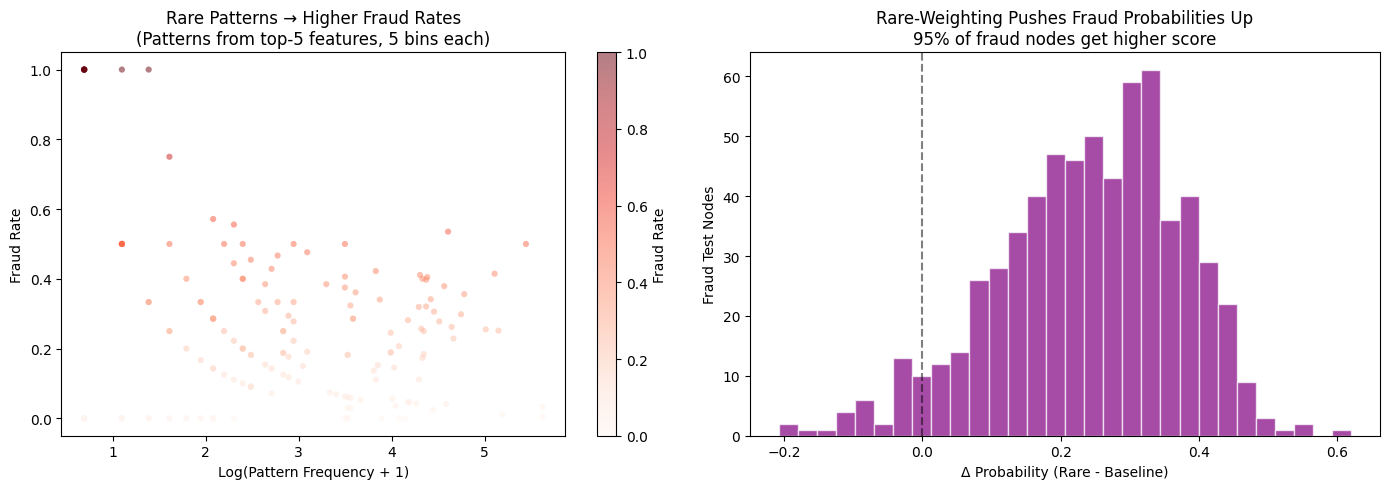


✅ RP-GAAP Demo Complete.
Rare-pattern weighting identifies uncommon feature combinations, assigns
higher training weight, and catches fraud the baseline misses — with no
architecture changes to the GAAP model.


In [37]:
# 11: Scatter — Pattern Frequency vs Fraud Rate

up_full, uinv_full, cnts_full = np.unique(pat_all[train_mask], return_inverse=True, return_counts=True)
fr_by_pat = np.array([lnp[train_mask][uinv_full == i].mean() for i in range(len(up_full))])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(np.log1p(cnts_full), fr_by_pat, c=fr_by_pat, cmap='Reds',
                     alpha=0.5, s=20, edgecolors='none')
axes[0].set_xlabel("Log(Pattern Frequency + 1)"); axes[0].set_ylabel("Fraud Rate")
axes[0].set_title("Rare Patterns → Higher Fraud Rates\n(Patterns from top-5 features, 5 bins each)")
plt.colorbar(sc, ax=axes[0], label='Fraud Rate')

# Baseline vs Rare: which fraud nodes get higher probability?
fraud_mask_test = lbl_all[test_nodes] == 1
delta_prob = prob_rare[test_nodes][fraud_mask_test] - prob_base[test_nodes][fraud_mask_test]
axes[1].hist(delta_prob, bins=30, alpha=0.7, color='purple', edgecolor='white')
axes[1].axvline(0, color='k', linestyle='--', alpha=0.5)
axes[1].set_xlabel("Δ Probability (Rare - Baseline)")
axes[1].set_ylabel("Fraud Test Nodes")
axes[1].set_title(f"Rare-Weighting Pushes Fraud Probabilities Up\n"
                  f"{(delta_prob > 0).mean()*100:.0f}% of fraud nodes get higher score")
plt.tight_layout(); plt.show()

print("\n✅ RP-GAAP Demo Complete.")
print("Rare-pattern weighting identifies uncommon feature combinations, assigns")
print("higher training weight, and catches fraud the baseline misses — with no")
print("architecture changes to the GAAP model.")
